In [4]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROUND_NUM = 3
BASE = './round3'
DAYS = ['0', '1', '2']
VOL_WINDOW = 500

# Load all price data
frames = []
for day in DAYS:
    df = pd.read_csv(f'{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv', sep=';')
    df['abs_ts'] = df['timestamp'] + int(day) * 1_000_000
    frames.append(df)

prices = pd.concat(frames, ignore_index=True)
prices = prices[prices['mid_price'].notna() & (prices['mid_price'] != 0)]

products = sorted(prices['product'].unique())
print(f'Products: {products}')
print(f'Days: {DAYS}  |  Total rows: {len(prices)}')

Products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Days: ['0', '1', '2']  |  Total rows: 360000


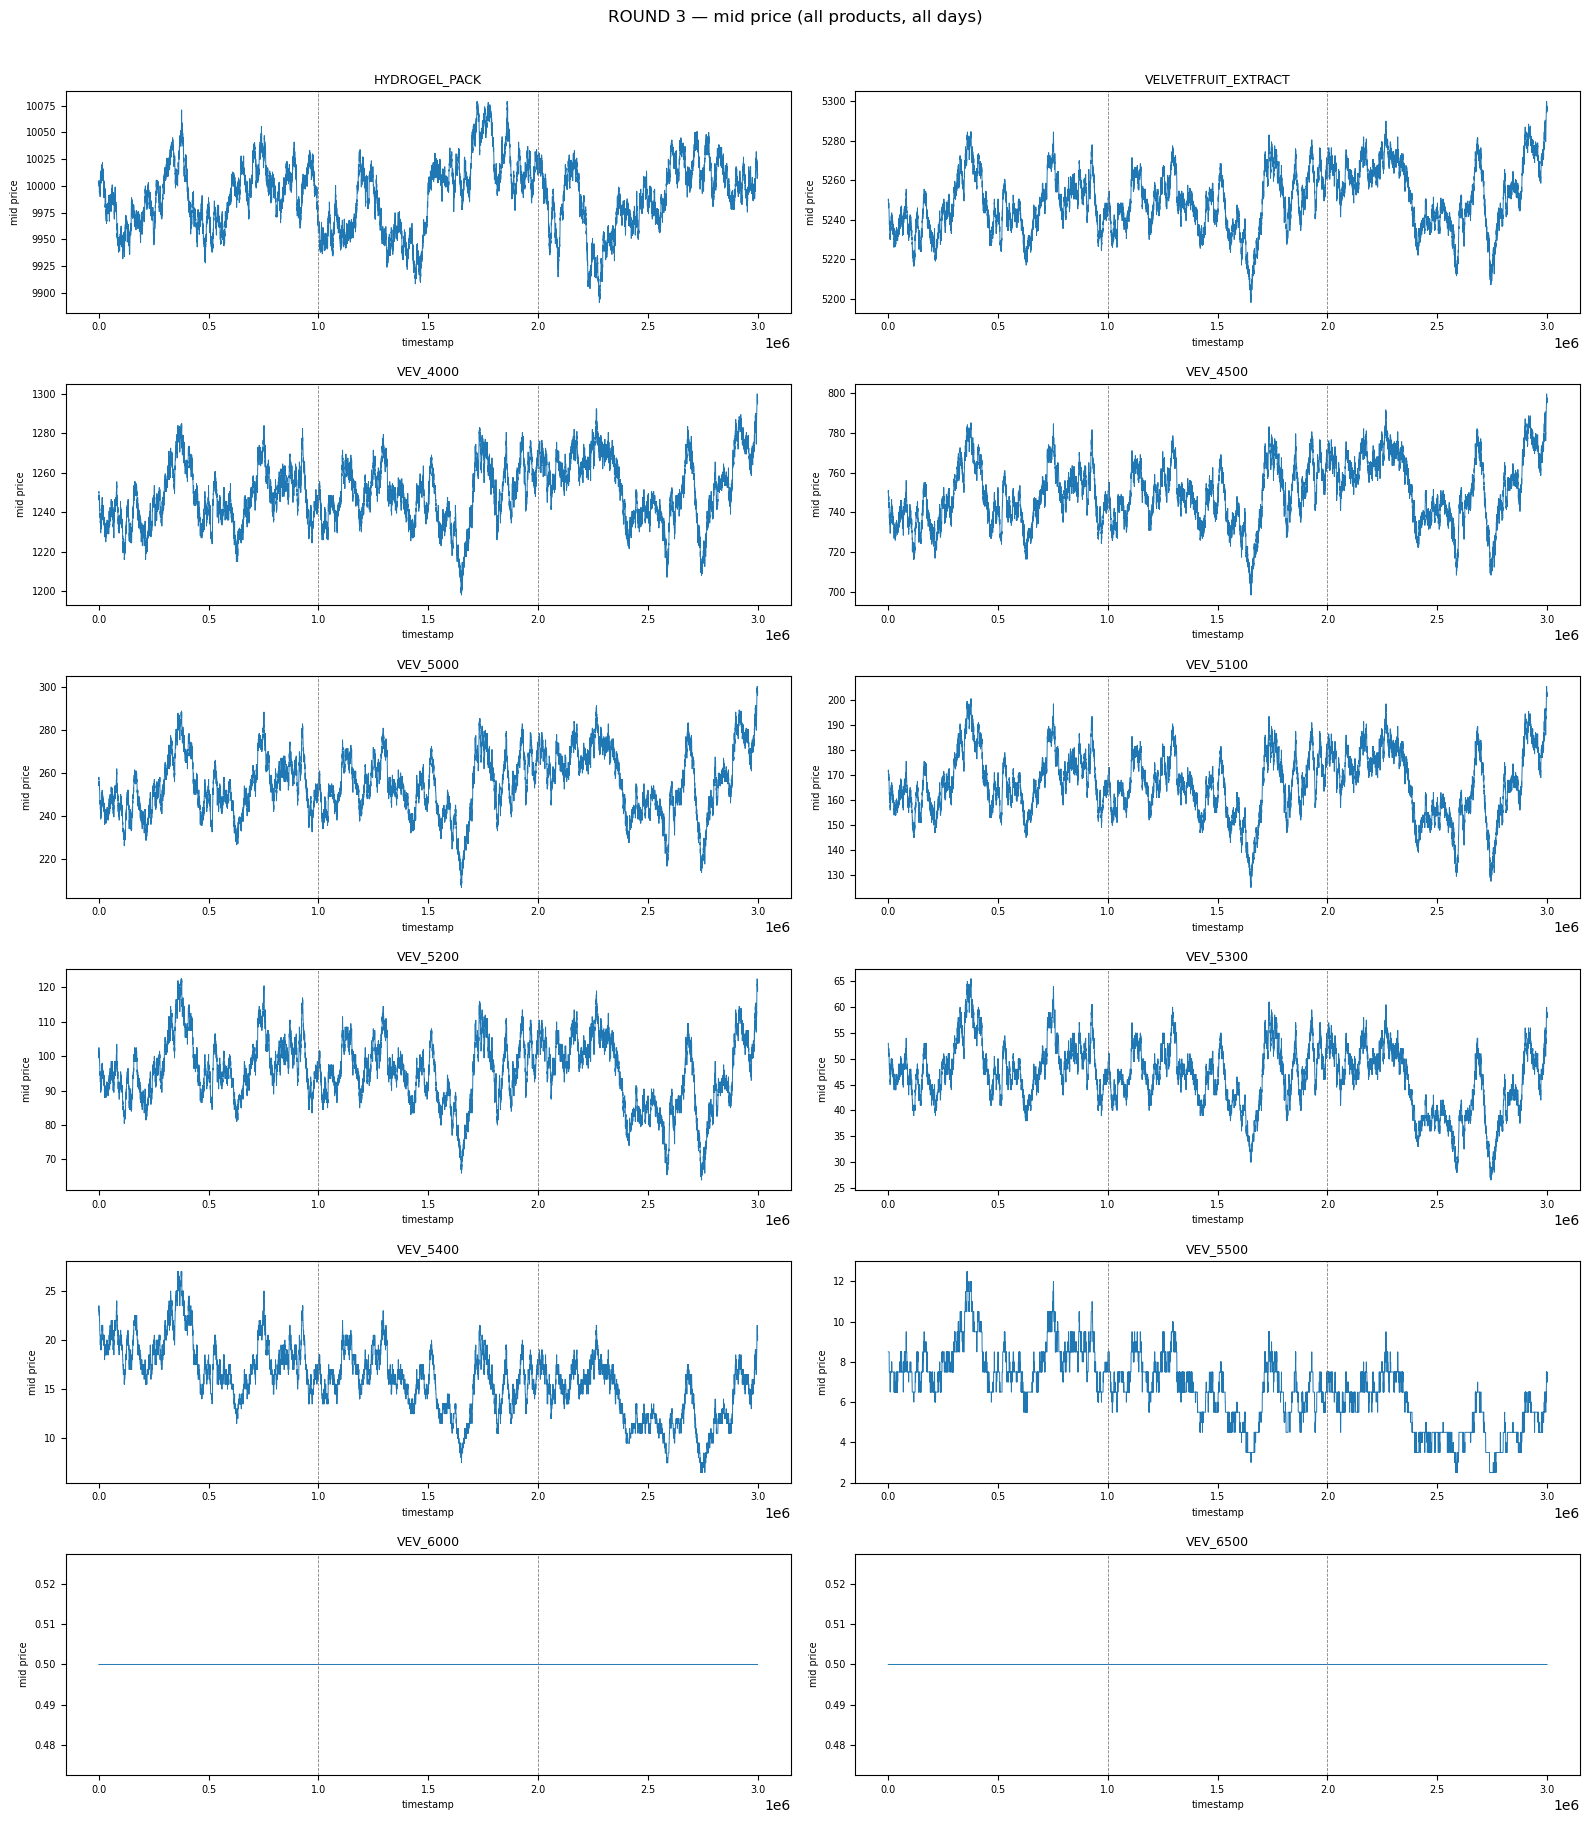

In [5]:
# Mid price — one subplot per product
n = len(products)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, prod in enumerate(products):
    ax = axes[i]
    sub = prices[prices['product'] == prod].sort_values('abs_ts')
    ax.plot(sub['abs_ts'], sub['mid_price'], lw=0.7)
    for sep in [1_000_000, 2_000_000]:
        ax.axvline(sep, color='gray', lw=0.6, ls='--')
    ax.set_title(prod, fontsize=9)
    ax.set_xlabel('timestamp', fontsize=7)
    ax.set_ylabel('mid price', fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ROUND 3 — mid price (all products, all days)', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
prices['product']['VEV']

0                    VEV_5400
1                    VEV_6500
2                    VEV_5500
3                    VEV_5200
4                    VEV_5300
                 ...         
359995    VELVETFRUIT_EXTRACT
359996               VEV_4500
359997               VEV_5400
359998               VEV_6500
359999               VEV_5500
Name: product, Length: 360000, dtype: object

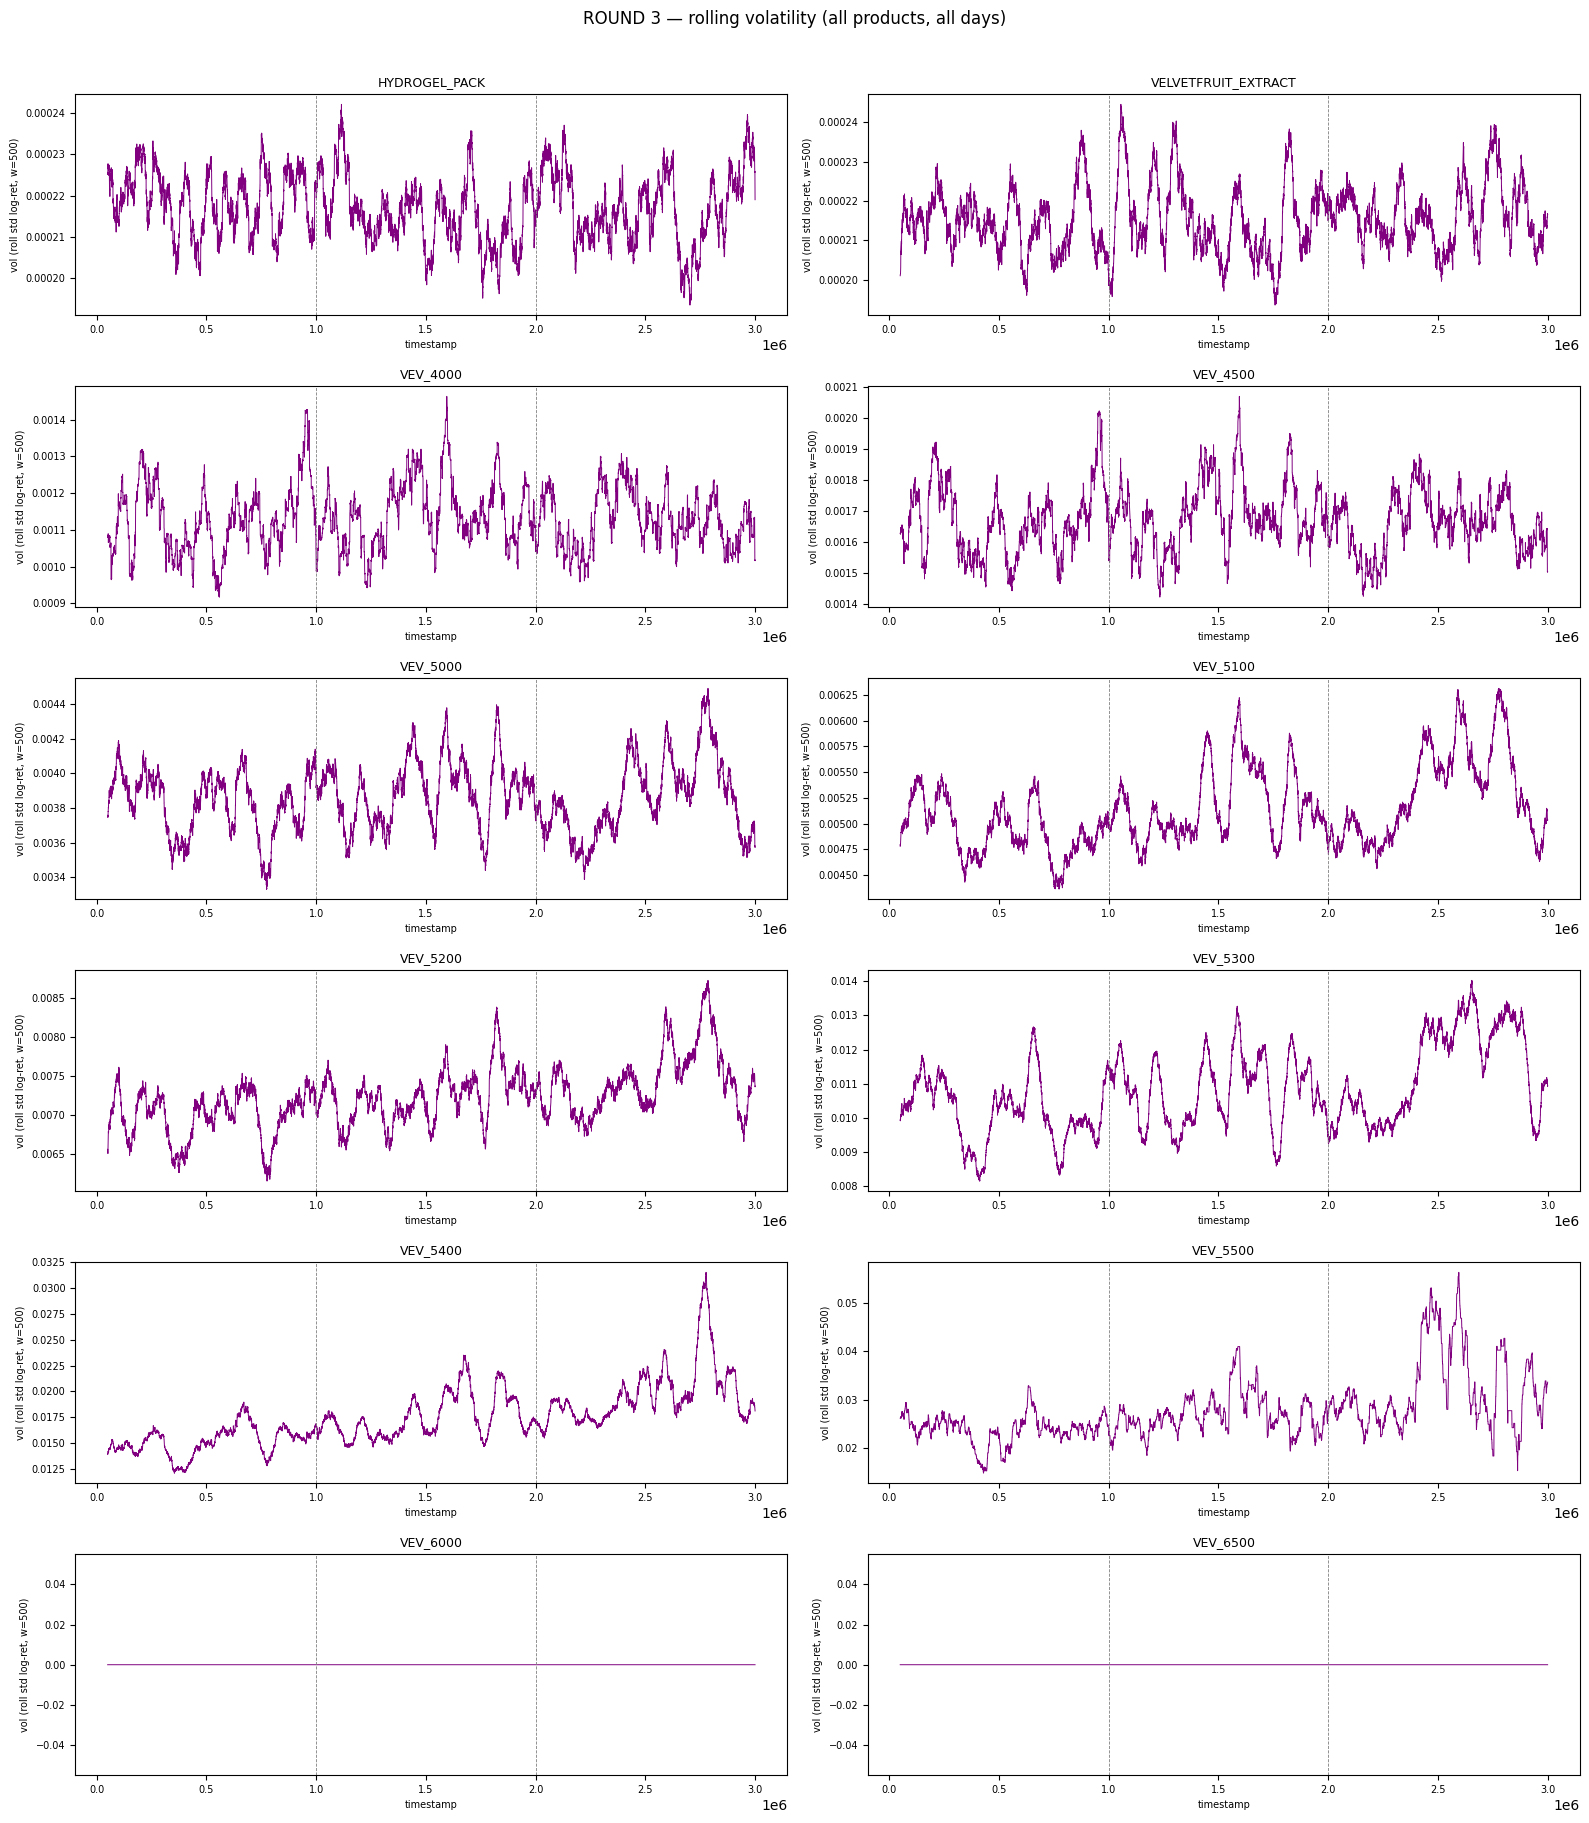

In [ ]:
# Rolling volatility — std of log returns, window=VOL_WINDOW ticks
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, prod in enumerate(products):
    ax = axes[i]
    sub = prices[prices['product'] == prod].sort_values('abs_ts')
    ts = sub['abs_ts'].values
    mid = sub['mid_price'].values

    log_ret = np.diff(np.log(mid))
    roll_vol = pd.Series(log_ret).rolling(VOL_WINDOW, min_periods=VOL_WINDOW).std().values

    ax.plot(ts[1:], roll_vol, lw=0.7, color='purple')
    for sep in [1_000_000, 2_000_000]:
        ax.axvline(sep, color='gray', lw=0.6, ls='--')
    ax.set_title(prod, fontsize=9)
    ax.set_xlabel('timestamp', fontsize=7)
    ax.set_ylabel(f'vol (roll std log-ret, w={VOL_WINDOW})', fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ROUND 3 — rolling volatility (all products, all days)', y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Vol summary table
rows = []
for prod in products:
    sub = prices[prices['product'] == prod].sort_values('abs_ts')
    log_ret = np.diff(np.log(sub['mid_price'].values))
    rows.append({
        'product': prod,
        'mean_vol': np.std(log_ret),
        'max_abs_ret': np.abs(log_ret).max(),
        'n_ticks': len(sub),
    })

summary = pd.DataFrame(rows).set_index('product').sort_values('mean_vol', ascending=False)
print(summary.to_string())

                     mean_vol  max_abs_ret  n_ticks
product                                            
VEV_5500             0.028554     0.251314    30000
VEV_5400             0.017724     0.111226    30000
VEV_5300             0.010858     0.054067    30000
VEV_5200             0.007224     0.033336    30000
VEV_5100             0.005154     0.023296    30000
VEV_5000             0.003861     0.020619    30000
VEV_4500             0.001671     0.011553    30000
VEV_4000             0.001134     0.008900    30000
HYDROGEL_PACK        0.000217     0.001156    30000
VELVETFRUIT_EXTRACT  0.000215     0.001046    30000
VEV_6000             0.000000     0.000000    30000
VEV_6500             0.000000     0.000000    30000


VEV mid:  mean=5250.098  std=15.630  n=30000
AR(2) MEAN (alpha/(1-b1-b2)) = 5250.95   ->   diff to empirical mean: -0.852


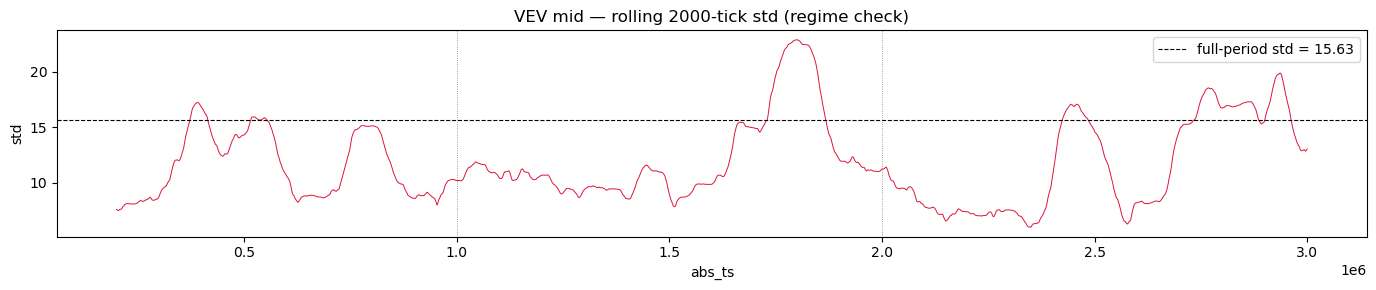

In [10]:
# VEV_STD for engine_ab.py — std dev of VELVETFRUIT_EXTRACT mid over full 3-day period.
# Used in Engine A skew formula: raw_skew = (fair_value - MEAN) / VEV_STD * SKEW_MAX
vev = prices[prices['product'] == 'VELVETFRUIT_EXTRACT'].sort_values('abs_ts')
vev_mid = vev['mid_price']
VEV_MEAN = vev_mid.mean()
VEV_STD  = vev_mid.std()
print(f'VEV mid:  mean={VEV_MEAN:.3f}  std={VEV_STD:.3f}  n={len(vev_mid)}')
print(f'AR(2) MEAN (alpha/(1-b1-b2)) = 5250.95   ->   diff to empirical mean: {VEV_MEAN - 5250.95:+.3f}')

# rolling std diagnostic — flag regime shifts
roll_std = vev_mid.rolling(2000).std()
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(vev['abs_ts'].values, roll_std.values, lw=0.7, color='crimson')
ax.axhline(VEV_STD, color='k', ls='--', lw=0.8, label=f'full-period std = {VEV_STD:.2f}')
for sep in [1_000_000, 2_000_000]:
    ax.axvline(sep, color='grey', ls=':', lw=0.6)
ax.set_title('VEV mid — rolling 2000-tick std (regime check)')
ax.set_xlabel('abs_ts'); ax.set_ylabel('std')
ax.legend()
plt.tight_layout(); plt.show()


In [ ]:
'''
# --- SETTINGS & MODELS ---
MEAN = alpha / (1 - beta1 - beta2)
STRIKES = [4000, 5200, 5300, 5400, 5500, 6000, 6500]
U_LIMIT = 200 # Underlying position limit
O_LIMIT = 300 # Per-option strike limit
REGRET_THRESHOLD = 1500 # Net Delta threshold to trigger "throttling"

# --- MAIN LOOP (EVERY TICK) ---
FUNCTION on_tick(market_state):
    # 1. UPDATE FORECASTS
    S_curr = market_state.underlying.mid
    S_prev = market_state.underlying.prev_mid
    # Predict next tick for short-term scalping bias
    S_next = (beta1 * S_curr) + (beta2 * S_prev) + alpha
    
    # 2. ENGINE A: UNDERLYING MEAN-REVERSION
    # Simple linear scaling: buy more as price drops below mean
    u_target = -1 * (S_curr - MEAN) * SCALE_FACTOR 
    u_order_size = clamp(u_target - current_u_pos, -U_LIMIT, U_LIMIT)
    execute_underlying_trade(u_order_size)

    # 3. ENGINE B: OPTIONS SCALPING (SABR + AR2)
    portfolio_delta = calculate_current_delta(current_u_pos, option_positions)
    
    FOR EACH strike IN STRIKES:
        # Use long-term mean as Forward price since expiry is Round 7
        fair_val = bs_call(MEAN, strike, T_expiry, SABR_IV(strike))
        
        # Calculate 'Lean' based on portfolio risk (Min-Max Regret)
        # If delta is too high, we lower our buy/sell prices to favor selling
        inventory_lean = portfolio_delta / REGRET_THRESHOLD 
        
        # Define quotes: Fair Value +/- Edge, adjusted by lean
        my_bid = fair_val - BASE_EDGE - (inventory_lean * SPREAD)
        my_ask = fair_val + BASE_EDGE - (inventory_lean * SPREAD)

        # 4. THROTTLING (SAFETY OVERLAY)
        # If we are dangerously Long Delta, cancel all Buy orders for calls
        IF portfolio_delta > REGRET_THRESHOLD:
            my_bid = 0 # Stop buying
        IF portfolio_delta < -REGRET_THRESHOLD:
            my_ask = 999999 # Stop selling

        # 5. EXECUTION: Market Making / Scalping
        # We provide liquidity at our calculated lean, capturing the 'ping-pong'
        place_limit_order(strike, my_bid, quantity=O_LIMIT)
        place_limit_order(strike, my_ask, quantity=O_LIMIT)

# --- SUPPORT FUNCTIONS ---
FUNCTION calculate_current_delta(u_pos, opt_positions):
    # Sum of underlying units + (option_qty * option_delta)
    # This represents our total exposure to a 1-unit move in the mean
    RETURN u_pos + SUM(opt.qty * opt.delta FOR opt IN opt_positions)

FUNCTION SABR_IV(strike):
    # Returns the IV from your calibrated SABR model
    # Accounts for the 'smile' across your specific strikes
    RETURN hagan_vol_formula(MEAN, strike, T_expiry, alpha, beta, rho, nu)
'''